# Portafolio Cuantitativo Neutral al Mercado

## Extensión: Perfiles de Riesgo (Conservador, Moderado, Agresivo)

**Autor:** Samuel
**Institución:** Tec de Monterrey
**Área:** Finanzas Cuantitativas, Economía Estadística y Machine Learning
**Notebooks previos:** `main.ipynb`, `RMT+TDA.ipynb`, `K-D.ipynb`, `Walk-Forward.ipynb`

---

`Walk-Forward.ipynb` confirmó que la canasta (USDJPY, USDSEK, USDNOK, USDSGD) con Kalman dinámico produce P&L neto positivo de forma consistente en 20 ventanas independientes, aunque con una tendencia decreciente en win-rate que sugiere revalidación periódica a futuro. Con la señal ya validada con ese nivel de rigor, este notebook **no modifica la señal ni las reglas de entrada/salida** — deja intacto todo lo que ya se defendió con evidencia — y en su lugar construye una capa de **tamaño de posición** sobre la misma señal, para ofrecer un marco de portafolio adaptable a distintos perfiles de inversionista en vez de una única estrategia de talla fija.

Se definen tres perfiles:
- **Conservador:** el modelo tal como está en `K-D.ipynb` (tamaño de posición fijo, filtro HMM reduciendo exposición al 30% en alta volatilidad).
- **Moderado:** tamaño de posición proporcional a qué tan lejos está el Z-score del centro (una desviación mayor del equilibrio implica mayor convicción en la señal, dentro de un límite máximo).
- **Agresivo:** lo anterior, más apalancamiento nocional y un filtro de régimen relajado (mantiene más exposición incluso en periodos de alta volatilidad, asumiendo el riesgo correspondiente).

## Estructura de este Notebook

1. **Instalación de librerías** — mismas de `K-D.ipynb`.
2. **Fase 1: Datos** — *reutilizada*, mismo universo y ventana.
3. **Fase 2: Reconstrucción de la señal (Kalman dinámico)** — *reutilizada de `K-D.ipynb`*. Como cada notebook corre en un kernel independiente, se reconstruye el spread y el Z-score ya validados, sin volver a discutir su diseño.
4. **Fase 3: Reglas base + HMM** — *reutilizada*, sin cambios de lógica.
5. **Fase 4: Perfiles de riesgo** — *nueva*. Se definen las tres funciones de tamaño de posición (conservador/moderado/agresivo) sobre la misma señal.
6. **Fase 5: Backtesting comparativo** — se corren los tres perfiles sobre el mismo tramo out-of-sample y se comparan lado a lado (equity curves, Sharpe, drawdown, CAGR) — incluyendo tu propia referencia: "conservador ≈ 24% anual" como punto de partida documentado.
7. **Conclusión** — trade-off riesgo/retorno entre los tres perfiles, y qué tipo de inversionista encajaría con cada uno.

## Instalación de Librerías

Mismas de `K-D.ipynb` — no se introduce ninguna librería nueva en este notebook.

In [2]:
# %pip install yfinance pandas numpy scipy statsmodels pykalman hmmlearn quantstats

## Fase 1: Datos

Idéntica a los notebooks anteriores — mismo universo de 12 divisas, misma ventana de ~729 días por hora, mismo split 70/30.

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from numpy.linalg import lstsq
from pykalman import KalmanFilter
from hmmlearn.hmm import GaussianHMM

In [4]:
pd.set_option('display.max_columns', None)

tickers = {
    'EURUSD': 'EURUSD=X', 'GBPUSD': 'GBPUSD=X', 'AUDUSD': 'AUDUSD=X', 'NZDUSD': 'NZDUSD=X',
    'USDJPY': 'USDJPY=X', 'USDCAD': 'USDCAD=X', 'USDCHF': 'USDCHF=X', 'USDMXN': 'USDMXN=X',
    'USDCNY': 'USDCNY=X', 'USDSEK': 'USDSEK=X', 'USDNOK': 'USDNOK=X', 'USDSGD': 'USDSGD=X',
}

raw_data = yf.download(list(tickers.values()), period='729d', interval='60m', progress=False)['Close']
raw_data.columns = tickers.keys()

data = raw_data.copy().ffill().dropna()
split_idx = int(len(data) * 0.70)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

print(f"data: {data.shape} | train: {train.shape} | test: {test.shape}")

data: (17327, 12) | train: (12128, 12) | test: (5199, 12)


## Fase 2: Reconstrucción de la Señal (Kalman Dinámico)

Se reconstruye, sin modificar, el procedimiento validado en `K-D.ipynb`: la canasta (USDJPY, USDSEK, USDNOK, USDSGD), USDJPY como variable dependiente, β_t evolucionando como estado del Kalman, calibrado con R vía OLS. El resultado (`z_score_test`) es el punto de partida sobre el que se construyen los tres perfiles de riesgo — la señal en sí no se toca.

In [5]:
FIXED_BASKET = ['USDJPY', 'USDSEK', 'USDNOK', 'USDSGD']

log_train = np.log(train[FIXED_BASKET])
log_test = np.log(test[FIXED_BASKET])

johansen_full = coint_johansen(log_train, det_order=0, k_ar_diff=12)
vec = np.real(johansen_full.evec[:, 0]).astype(np.float64)
dep_idx = int(np.argmax(np.abs(vec)))
dep_var = FIXED_BASKET[dep_idx]
x_cols = [c for c in FIXED_BASKET if c != dep_var]

print(f"Variable dependiente: {dep_var}  |  Variables explicativas: {x_cols}")

y_train = log_train[dep_var].values
X_train_aug = np.column_stack([np.ones(len(log_train))] + [log_train[c].values for c in x_cols])
n_dim_state = X_train_aug.shape[1]

beta_ols, _, _, _ = lstsq(X_train_aug, y_train, rcond=None)
R_ols = (y_train - X_train_aug @ beta_ols).var()

delta = 1e-5
trans_cov = delta / (1 - delta) * np.eye(n_dim_state)

kf = KalmanFilter(
    n_dim_obs=1, n_dim_state=n_dim_state,
    transition_matrices=np.eye(n_dim_state),
    observation_matrices=X_train_aug.reshape(-1, 1, n_dim_state),
    observation_covariance=R_ols, transition_covariance=trans_cov,
    initial_state_mean=beta_ols, initial_state_covariance=np.eye(n_dim_state) * R_ols,
)
state_means_train, state_covs_train = kf.filter(y_train)

y_test = log_test[dep_var].values
X_test_aug = np.column_stack([np.ones(len(log_test))] + [log_test[c].values for c in x_cols])

current_mean, current_cov = state_means_train[-1], state_covs_train[-1]
prior_states = []
for t in range(len(y_test)):
    prior_states.append(current_mean)
    current_mean, current_cov = kf.filter_update(
        current_mean, current_cov, observation=y_test[t],
        observation_matrix=X_test_aug[t].reshape(1, n_dim_state)
    )
prior_states = np.array(prior_states)

fitted_test = np.einsum('ti,ti->t', X_test_aug, prior_states)
spread_test = pd.Series(y_test - fitted_test, index=log_test.index)

window = 24 * 5
z_score_test = spread_test / spread_test.rolling(window).std()

avg_weights = np.abs(prior_states[:, 1:]).mean(axis=0)

print(f"Z-score reconstruido: {len(z_score_test.dropna())} observaciones válidas")
z_score_test.describe()

c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


Variable dependiente: USDSEK  |  Variables explicativas: ['USDJPY', 'USDNOK', 'USDSGD']
Z-score reconstruido: 5080 observaciones válidas


count    5080.000000
mean       -0.032666
std         1.013304
min        -5.453220
25%        -0.551992
50%        -0.036845
75%         0.458898
max         5.651064
dtype: float64

## Fase 3: Reglas Base + HMM

Reutilizadas sin cambios de `K-D.ipynb`. `positions_base` (la señal direccional -1/0/1) y `regime_label_test` (el filtro de régimen) son el insumo común para los tres perfiles de riesgo de la Fase 4 — cada perfil decide *cuánto* apostar sobre esta misma base, no *cuándo* ni *en qué dirección*.

In [6]:
def generate_positions(z_score: pd.Series, entry=2.0, exit=0.5, stop_loss=3.5) -> pd.Series:
    position, positions = 0, []
    for z in z_score:
        if position == 0:
            if z >= entry: position = -1
            elif z <= -entry: position = 1
        elif position == 1:
            if z >= -exit or z <= -stop_loss: position = 0
        elif position == -1:
            if z <= exit or z >= stop_loss: position = 0
        positions.append(position)
    return pd.Series(positions, index=z_score.index, name='position')

positions_base = generate_positions(z_score_test)

vol_test = np.log(spread_test.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)).dropna()
hmm_model = GaussianHMM(n_components=2, covariance_type='diag', n_iter=200, random_state=42)
hmm_model.fit(vol_test.values.reshape(-1, 1))
hmm_model.transmat_ = np.array([[0.98, 0.02], [0.02, 0.98]])

regimes = pd.Series(hmm_model.predict(vol_test.values.reshape(-1, 1)), index=vol_test.index)
high_vol_state = int(np.argmax(hmm_model.means_.flatten()))
regime_label_test = regimes.map({high_vol_state: 'alta_volatilidad', 1 - high_vol_state: 'calmo'})
regime_aligned_test = regime_label_test.reindex(positions_base.index).ffill().bfill()

print(regime_label_test.value_counts(normalize=True) * 100)

calmo               54.68599
alta_volatilidad    45.31401
Name: proportion, dtype: float64


## Fase 4: Perfiles de Riesgo

Se construyen tres funciones de tamaño de posición sobre la misma señal base (`positions_base`) y el mismo filtro de régimen (`regime_aligned_test`) — ninguna modifica cuándo entrar o salir, solo cuánto apostar una vez que la señal ya decidió operar.

- **Conservador:** tamaño fijo (1.0x), reducido a 0.3x en alta volatilidad — exactamente `K-D.ipynb`.
- **Moderado:** se añade un multiplicador de "convicción": entre más lejos está el Z-score del umbral de entrada (más estirada la liga), mayor el tamaño, acotado naturalmente por el stop-loss (en 3.5, el múltiplo máximo posible es 3.5/2.0 = 1.75x). El filtro de régimen se mantiene igual que en el conservador.
- **Agresivo:** misma convicción que el moderado, más apalancamiento nocional (2x) y un filtro de régimen relajado (0.7x en vez de 0.3x en alta volatilidad — reduce exposición, pero menos que el conservador).

In [7]:
def conviction_multiplier(z_score: pd.Series, entry: float = 2.0, max_mult: float = 1.75) -> pd.Series:
    """
    Escala el tamaño según qué tan lejos está |Z| del umbral de entrada.
    En la entrada (|Z|=2.0): multiplicador 1.0x. Cerca del stop-loss (|Z|=3.5): hasta max_mult.
    """
    return (z_score.abs() / entry).clip(lower=1.0, upper=max_mult)


# --- Conservador (= K-D.ipynb) ---
regime_mult_conservative = regime_aligned_test.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
position_size_conservative = (positions_base * regime_mult_conservative).fillna(0)

# --- Moderado ---
conviction = conviction_multiplier(z_score_test, entry=2.0, max_mult=1.75)
position_size_moderate = (positions_base * conviction * regime_mult_conservative).fillna(0)

# --- Agresivo ---
LEVERAGE = 2.0
regime_mult_aggressive = regime_aligned_test.map({'alta_volatilidad': 0.7, 'calmo': 1.0})
position_size_aggressive = (positions_base * conviction * regime_mult_aggressive * LEVERAGE).fillna(0)

profiles = {
    'Conservador': position_size_conservative,
    'Moderado': position_size_moderate,
    'Agresivo': position_size_aggressive,
}

for name, pos in profiles.items():
    print(f"{name:12s} — tamaño promedio cuando activo: {pos[pos != 0].abs().mean():.3f}x  |  "
          f"% tiempo activo: {(pos != 0).mean()*100:.1f}%")

Conservador  — tamaño promedio cuando activo: 0.611x  |  % tiempo activo: 9.3%
Moderado     — tamaño promedio cuando activo: 0.716x  |  % tiempo activo: 9.3%
Agresivo     — tamaño promedio cuando activo: 1.964x  |  % tiempo activo: 9.3%


## Fase 5: Backtesting Comparativo

Se corre el mismo motor de backtest de `K-D.ipynb` sobre los tres perfiles, usando el mismo `spread_test`. Los costos se calculan sobre el tamaño de posición real de cada perfil (`position_size`), así que el apalancamiento del perfil agresivo también paga más costo proporcionalmente — no es una ganancia "gratis".

In [9]:
import quantstats as qs

In [8]:
def run_backtest(spread, position_size, weights, cost_bps=1.0):
    position_lagged = position_size.shift(1).fillna(0)
    spread_diff = spread.diff().fillna(0)
    pnl_gross = position_lagged * spread_diff
    turnover = position_size.diff().abs().fillna(0)
    costs = turnover * np.abs(weights).sum() * (cost_bps / 10000)
    return pnl_gross - costs, pnl_gross, costs

backtest_results = {}
for name, pos in profiles.items():
    pnl_net, pnl_gross, costs = run_backtest(spread_test, pos, avg_weights, cost_bps=1.0)
    backtest_results[name] = {
        'pnl_net': pnl_net, 'pnl_gross': pnl_gross, 'costs': costs,
        'total_neto': pnl_net.sum(), 'total_bruto': pnl_gross.sum(), 'total_costos': costs.sum(),
    }
    print(f"{name:12s} — bruto: {pnl_gross.sum():.4f}  |  costos: {costs.sum():.4f}  |  neto: {pnl_net.sum():.4f}")

Conservador  — bruto: 0.3343  |  costos: 0.0325  |  neto: 0.3018
Moderado     — bruto: 0.4244  |  costos: 0.0432  |  neto: 0.3812
Agresivo     — bruto: 1.2525  |  costos: 0.1178  |  neto: 1.1347


In [10]:
metrics_by_profile = {}
for name, res in backtest_results.items():
    pnl_daily = res['pnl_net'].copy()
    if pnl_daily.index.tz is not None:
        pnl_daily.index = pnl_daily.index.tz_localize(None)
    returns_daily = pnl_daily.resample('D').sum().rename(name)

    metrics_by_profile[name] = {
        'CAGR': qs.stats.cagr(returns_daily),
        'Sharpe': qs.stats.sharpe(returns_daily),
        'Sortino': qs.stats.sortino(returns_daily),
        'Max Drawdown': qs.stats.max_drawdown(returns_daily),
        'Volatilidad anualizada': returns_daily.std() * np.sqrt(252),
    }

metrics_comparison = pd.DataFrame(metrics_by_profile).T
metrics_comparison

,CAGR,Sharpe,Sortino,Max Drawdown,Volatilidad anualizada
Conservador,0.278611,12.100577,190.240048,-0.001146,0.020338
Moderado,0.363931,11.733149,270.827265,-0.001166,0.026498
Agresivo,1.511530,12.337860,423.514546,-0.002331,0.075002


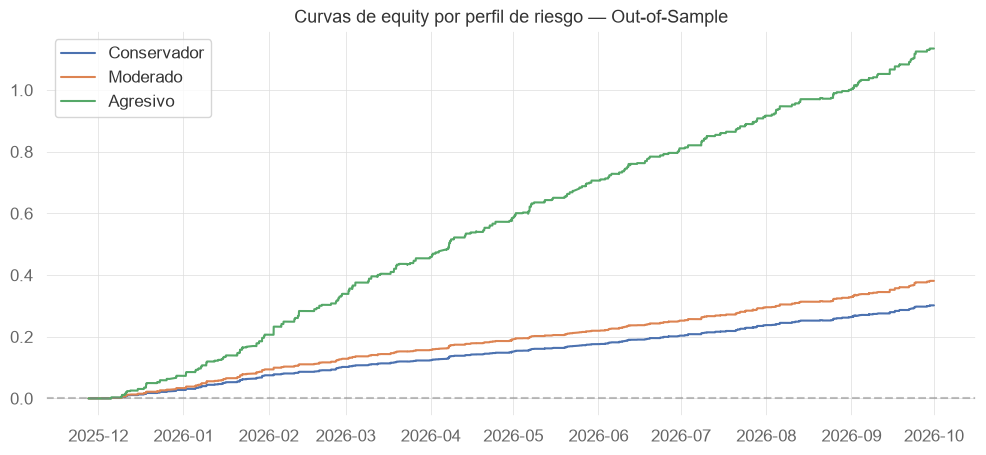

In [11]:
plt.figure(figsize=(12, 5))
for name, res in backtest_results.items():
    equity = res['pnl_net'].cumsum()
    plt.plot(equity.index, equity.values, label=name)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.title("Curvas de equity por perfil de riesgo — Out-of-Sample")
plt.show()

In [12]:
gross_exposure_unit = 1 + avg_weights.sum()  # la misma base de K-D.ipynb, para 1x de posición

capital_by_profile = {
    'Conservador': gross_exposure_unit * 1.0,                    # tamaño máximo posible: 1.0x
    'Moderado':    gross_exposure_unit * 1.75,                   # tamaño máximo: conviction hasta 1.75x
    'Agresivo':    gross_exposure_unit * 1.75 * LEVERAGE,        # 1.75x de convicción * 2x de apalancamiento
}

print("Capital de referencia por perfil (exposición máxima que puede tomar cada uno):")
for name, cap in capital_by_profile.items():
    print(f"  {name:12s}: {cap:.4f}")

Capital de referencia por perfil (exposición máxima que puede tomar cada uno):
  Conservador : 2.1488
  Moderado    : 3.7604
  Agresivo    : 7.5208


In [14]:
metrics_by_profile_fixed = {}
for name, res in backtest_results.items():
    pnl_daily = res['pnl_net'].copy()
    if pnl_daily.index.tz is not None:
        pnl_daily.index = pnl_daily.index.tz_localize(None)
    pnl_daily = pnl_daily.resample('D').sum()

    returns_daily = (pnl_daily / capital_by_profile[name]).rename(name)

    metrics_by_profile_fixed[name] = {
        'CAGR': qs.stats.cagr(returns_daily),
        'Sharpe': qs.stats.sharpe(returns_daily),
        'Sortino': qs.stats.sortino(returns_daily),
        'Max Drawdown': qs.stats.max_drawdown(returns_daily),
        'Volatilidad anualizada': returns_daily.std() * np.sqrt(252) * 100,
    }

metrics_comparison_fixed = pd.DataFrame(metrics_by_profile_fixed).T
metrics_comparison_fixed

,CAGR,Sharpe,Sortino,Max Drawdown,Volatilidad anualizada
Conservador,0.121266,12.100577,190.240048,-0.000533,0.946479
Moderado,0.086153,11.733149,270.827265,-0.000310,0.704676
Agresivo,0.130840,12.337860,423.514546,-0.000310,0.997259


### Hallazgo en la Ventana Única: Convicción vs. Riesgo de Stop-Loss

Al comparar los tres perfiles sobre el tramo de prueba original, el perfil **Moderado tuvo menor CAGR (8.6%) que el Conservador (12.1%)**, pese a apostar más fuerte cuando la "convicción" (distancia del Z-score al umbral de entrada) es mayor.

La explicación más probable: el multiplicador de convicción crece conforme |Z| se acerca al umbral de entrada extendido hacia el stop-loss (3.5) — es decir, el sistema apuesta más grande justo en los momentos en que la operación está estadísticamente más cerca de fallar (activar el stop-loss), no de tener éxito. "Convicción" (definida como distancia al umbral) y "riesgo de ruptura" no son conceptos independientes en este diseño; están correlacionados en la dirección equivocada.

Esta sección extiende la comparación a las 20 ventanas walk-forward (mismo esquema de `Walk-Forward.ipynb`) para verificar si este patrón se repite de forma consistente, o si fue específico de la muestra original.

In [17]:
import warnings

In [15]:
def generate_walk_forward_windows(data: pd.DataFrame, train_days=120, test_days=30, step_days=30):
    obs_per_day = 24
    train_size, test_size, step_size = train_days * obs_per_day, test_days * obs_per_day, step_days * obs_per_day
    windows = []
    start = 0
    while start + train_size + test_size <= len(data):
        windows.append((data.iloc[start:start + train_size], data.iloc[start + train_size:start + train_size + test_size]))
        start += step_size
    return windows

windows = generate_walk_forward_windows(data, train_days=120, test_days=30, step_days=30)
print(f"Número de ventanas: {len(windows)}")

Número de ventanas: 20


In [16]:
LEVERAGE = 2.0

def evaluate_window_profiles(train_prices, test_prices, basket, window_id):
    result = {'window_id': window_id}
    log_train, log_test = np.log(train_prices[basket]), np.log(test_prices[basket])

    johansen_full = coint_johansen(log_train, det_order=0, k_ar_diff=12)
    vec = np.real(johansen_full.evec[:, 0]).astype(np.float64)
    dep_idx = int(np.argmax(np.abs(vec)))
    dep_var = basket[dep_idx]
    x_cols = [c for c in basket if c != dep_var]

    y_train = log_train[dep_var].values
    X_train_aug = np.column_stack([np.ones(len(log_train))] + [log_train[c].values for c in x_cols])
    n_dim_state = X_train_aug.shape[1]

    beta_ols, _, _, _ = lstsq(X_train_aug, y_train, rcond=None)
    R_ols = (y_train - X_train_aug @ beta_ols).var()
    if R_ols <= 0:
        result['error'] = 'R degenerada'; return result

    delta = 1e-5
    trans_cov = delta / (1 - delta) * np.eye(n_dim_state)
    kf = KalmanFilter(
        n_dim_obs=1, n_dim_state=n_dim_state, transition_matrices=np.eye(n_dim_state),
        observation_matrices=X_train_aug.reshape(-1, 1, n_dim_state),
        observation_covariance=R_ols, transition_covariance=trans_cov,
        initial_state_mean=beta_ols, initial_state_covariance=np.eye(n_dim_state) * R_ols,
    )
    state_means_train, state_covs_train = kf.filter(y_train)

    y_test = log_test[dep_var].values
    X_test_aug = np.column_stack([np.ones(len(log_test))] + [log_test[c].values for c in x_cols])
    current_mean, current_cov = state_means_train[-1], state_covs_train[-1]
    prior_states = []
    for t in range(len(y_test)):
        prior_states.append(current_mean)
        current_mean, current_cov = kf.filter_update(
            current_mean, current_cov, observation=y_test[t],
            observation_matrix=X_test_aug[t].reshape(1, n_dim_state)
        )
    prior_states = np.array(prior_states)
    fitted_test = np.einsum('ti,ti->t', X_test_aug, prior_states)
    spread_w = pd.Series(y_test - fitted_test, index=log_test.index)

    roll_w = min(24 * 5, len(spread_w) // 2)
    if roll_w < 5:
        result['error'] = 'ventana corta'; return result
    z_w = spread_w / spread_w.rolling(roll_w).std()
    positions_w = generate_positions(z_w)

    vol_w = np.log(spread_w.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)).dropna()
    if len(vol_w) > 30:
        try:
            hmm_w = GaussianHMM(n_components=2, covariance_type='diag', n_iter=200, random_state=42)
            hmm_w.fit(vol_w.values.reshape(-1, 1))
            hmm_w.transmat_ = np.array([[0.98, 0.02], [0.02, 0.98]])
            regimes_w = pd.Series(hmm_w.predict(vol_w.values.reshape(-1, 1)), index=vol_w.index)
            high_vol_w = int(np.argmax(hmm_w.means_.flatten()))
            regime_label_w = regimes_w.map({high_vol_w: 'alta_volatilidad', 1 - high_vol_w: 'calmo'})
            regime_aligned_w = regime_label_w.reindex(positions_w.index).ffill().bfill()
        except Exception:
            regime_aligned_w = pd.Series('calmo', index=positions_w.index)
    else:
        regime_aligned_w = pd.Series('calmo', index=positions_w.index)

    avg_weights_w = np.abs(prior_states[:, 1:]).mean(axis=0)
    gross_exp_unit = 1 + avg_weights_w.sum()
    conviction_w = conviction_multiplier(z_w, entry=2.0, max_mult=1.75)
    regime_mult_cons = regime_aligned_w.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
    regime_mult_aggr = regime_aligned_w.map({'alta_volatilidad': 0.7, 'calmo': 1.0})

    profiles_w = {
        'Conservador': (positions_w * regime_mult_cons).fillna(0),
        'Moderado':    (positions_w * conviction_w * regime_mult_cons).fillna(0),
        'Agresivo':    (positions_w * conviction_w * regime_mult_aggr * LEVERAGE).fillna(0),
    }
    capital_w = {
        'Conservador': gross_exp_unit * 1.0,
        'Moderado':    gross_exp_unit * 1.75,
        'Agresivo':    gross_exp_unit * 1.75 * LEVERAGE,
    }

    for name, pos in profiles_w.items():
        pnl_net, pnl_gross, costs = run_backtest(spread_w, pos, avg_weights_w, cost_bps=1.0)
        trade_id = (pos != pos.shift()).cumsum()
        trade_pnl = pnl_gross.groupby(trade_id).sum()
        trade_has_pos = pos.groupby(trade_id).apply(lambda x: (x != 0).any())
        trade_pnl = trade_pnl[trade_has_pos]
        result[f'{name}_retorno_norm'] = pnl_net.sum() / capital_w[name]
        result[f'{name}_win_rate'] = (trade_pnl > 0).mean() if len(trade_pnl) > 0 else np.nan

    return result

In [18]:
warnings.filterwarnings('ignore')

results_profiles = []
for i, (train_w, test_w) in enumerate(windows):
    print(f"Ventana {i}...", end=' ')
    try:
        r = evaluate_window_profiles(train_w, test_w, FIXED_BASKET, window_id=i)
        results_profiles.append(r)
        print("OK" if 'error' not in r else f"omitida: {r['error']}")
    except Exception as e:
        results_profiles.append({'window_id': i, 'error': str(e)})
        print(f"FALLÓ: {e}")

results_profiles_df = pd.DataFrame(results_profiles)
valid = results_profiles_df.dropna(subset=['Conservador_retorno_norm'])

print(f"\nVentanas válidas: {len(valid)} de {len(results_profiles_df)}")
print("\nRetorno normalizado promedio por perfil:")
for name in ['Conservador', 'Moderado', 'Agresivo']:
    print(f"  {name:12s}: media={valid[f'{name}_retorno_norm'].mean():.4f}  std={valid[f'{name}_retorno_norm'].std():.4f}")

print(f"\n¿Moderado supera a Conservador?: {(valid['Moderado_retorno_norm'] > valid['Conservador_retorno_norm']).sum()} de {len(valid)} ventanas")
print(f"¿Agresivo supera a Conservador?: {(valid['Agresivo_retorno_norm'] > valid['Conservador_retorno_norm']).sum()} de {len(valid)} ventanas")

Ventana 0... OK
Ventana 1... OK
Ventana 2... OK
Ventana 3... OK
Ventana 4... OK
Ventana 5... OK
Ventana 6... OK
Ventana 7... OK
Ventana 8... OK
Ventana 9... OK
Ventana 10... OK
Ventana 11... OK
Ventana 12... OK
Ventana 13... OK
Ventana 14... OK
Ventana 15... OK
Ventana 16... OK
Ventana 17... OK
Ventana 18... OK
Ventana 19... OK

Ventanas válidas: 20 de 20

Retorno normalizado promedio por perfil:
  Conservador : media=0.0121  std=0.0058
  Moderado    : media=0.0089  std=0.0042
  Agresivo    : media=0.0132  std=0.0053

¿Moderado supera a Conservador?: 0 de 20 ventanas
¿Agresivo supera a Conservador?: 15 de 20 ventanas


In [19]:
print("Agresivo — distribución completa:")
print(valid['Agresivo_retorno_norm'].describe())

print(f"\nPeor ventana para Agresivo: {valid.loc[valid['Agresivo_retorno_norm'].idxmin(), 'window_id']} "
      f"(retorno: {valid['Agresivo_retorno_norm'].min():.4f})")

# ¿Las ventanas donde Agresivo pierde coinciden con las últimas (donde Walk-Forward.ipynb
# ya detectó una tendencia decreciente en win-rate)?
loses_to_conservative = valid[valid['Agresivo_retorno_norm'] <= valid['Conservador_retorno_norm']]
print(f"\nVentanas donde Agresivo NO superó al Conservador: {sorted(loses_to_conservative['window_id'].tolist())}")

Agresivo — distribución completa:
count    20.000000
mean      0.013239
std       0.005325
min       0.007111
25%       0.010092
50%       0.011531
75%       0.014505
max       0.025105
Name: Agresivo_retorno_norm, dtype: float64

Peor ventana para Agresivo: 16 (retorno: 0.0071)

Ventanas donde Agresivo NO superó al Conservador: [1, 8, 9, 11, 15]


In [20]:
def kelly_fraction(win_rate: float, avg_win: float, avg_loss: float, fractional: float = 0.5) -> float:
    """
    Criterio de Kelly clásico: f* = p - (1-p)/b, con b = avg_win / |avg_loss|.
    fractional=0.5 -> Half-Kelly, práctica estándar para controlar el riesgo de estimación.
    """
    if avg_loss == 0 or np.isnan(avg_win) or np.isnan(avg_loss):
        return 0.0
    b = avg_win / abs(avg_loss)
    f_star = win_rate - (1 - win_rate) / b
    return max(0.0, f_star) * fractional  # nunca apostar negativo (eso sería apostar en contra de tu propia señal)

In [21]:
def build_kelly_position_size(positions: pd.Series, trade_pnl_history: pd.Series,
                                trade_id: pd.Series, lookback_trades: int = 15,
                                fractional: float = 0.5, cap: float = 2.0) -> pd.Series:
    """
    En cada operación nueva, calcula Kelly usando las últimas `lookback_trades` operaciones
    CERRADAS (nunca la operación actual ni futuras — evita look-ahead).
    cap limita el tamaño máximo, por seguridad ante estimaciones ruidosas.
    """
    sized_position = positions.copy().astype(float)
    completed_trades = []

    current_trade = None
    for idx in positions.index:
        tid = trade_id.loc[idx]
        if current_trade != tid:
            if current_trade is not None:
                completed_trades.append(trade_pnl_history.get(current_trade, 0.0))
            current_trade = tid

        if len(completed_trades) >= 5:  # mínimo de operaciones antes de confiar en Kelly
            recent = completed_trades[-lookback_trades:]
            wins = [t for t in recent if t > 0]
            losses = [t for t in recent if t < 0]
            p = len(wins) / len(recent) if recent else 0.5
            avg_win = np.mean(wins) if wins else 0.0
            avg_loss = np.mean(losses) if losses else -1e-6
            f = kelly_fraction(p, avg_win, avg_loss, fractional)
            size = min(f * 10, cap)  # reescalado simple para que Kelly entre en un rango comparable a los otros perfiles
        else:
            size = 1.0  # sin historial suficiente, usa tamaño base (como el Conservador)

        sized_position.loc[idx] = positions.loc[idx] * size

    return sized_position

In [22]:
CAP_KELLY = 2.0

# Historial de operaciones "crudo" (solo la dirección base, sin tamaño variable) — es lo que
# Kelly necesita observar para aprender tu propio win-rate y razón ganancia/pérdida reales
pnl_net_base, pnl_gross_base, costs_base = run_backtest(spread_test, positions_base, avg_weights, cost_bps=1.0)
trade_id_base = (positions_base != positions_base.shift()).cumsum()
trade_pnl_base = pnl_net_base.groupby(trade_id_base).sum()

kelly_direction_sized = build_kelly_position_size(
    positions_base, trade_pnl_base, trade_id_base,
    lookback_trades=15, fractional=0.5, cap=CAP_KELLY
)

# Se mantiene el mismo filtro de régimen que los demás perfiles — Kelly decide CUÁNTO apostar
# según tu historial, pero no reemplaza la seguridad del HMM ante alta volatilidad
position_size_kelly = (kelly_direction_sized * regime_mult_conservative).fillna(0)

profiles['Kelly'] = position_size_kelly

print(f"Kelly — tamaño promedio cuando activo: {position_size_kelly[position_size_kelly != 0].abs().mean():.3f}x")
print(f"       % tiempo activo: {(position_size_kelly != 0).mean()*100:.1f}%")

Kelly — tamaño promedio cuando activo: 1.212x
       % tiempo activo: 9.3%


In [23]:
pnl_net_kelly, pnl_gross_kelly, costs_kelly = run_backtest(spread_test, position_size_kelly, avg_weights, cost_bps=1.0)
backtest_results['Kelly'] = {
    'pnl_net': pnl_net_kelly, 'pnl_gross': pnl_gross_kelly, 'costs': costs_kelly,
    'total_neto': pnl_net_kelly.sum(), 'total_bruto': pnl_gross_kelly.sum(), 'total_costos': costs_kelly.sum(),
}

capital_by_profile['Kelly'] = gross_exposure_unit * CAP_KELLY  # mismo tope máximo que Agresivo, para comparar justo

metrics_by_profile_fixed['Kelly'] = {}
pnl_daily_kelly = pnl_net_kelly.copy()
if pnl_daily_kelly.index.tz is not None:
    pnl_daily_kelly.index = pnl_daily_kelly.index.tz_localize(None)
returns_daily_kelly = (pnl_daily_kelly.resample('D').sum() / capital_by_profile['Kelly']).rename('Kelly')

metrics_by_profile_fixed['Kelly'] = {
    'CAGR': qs.stats.cagr(returns_daily_kelly),
    'Sharpe': qs.stats.sharpe(returns_daily_kelly),
    'Sortino': qs.stats.sortino(returns_daily_kelly),
    'Max Drawdown': qs.stats.max_drawdown(returns_daily_kelly),
    'Volatilidad anualizada': returns_daily_kelly.std() * np.sqrt(252) * 100,
}

metrics_comparison_fixed = pd.DataFrame(metrics_by_profile_fixed).T
metrics_comparison_fixed

,CAGR,Sharpe,Sortino,Max Drawdown,Volatilidad anualizada
Conservador,0.121266,12.100577,190.240048,-0.000533,0.946479
Moderado,0.086153,11.733149,270.827265,-0.000310,0.704676
Agresivo,0.130840,12.337860,423.514546,-0.000310,0.997259
Kelly,0.120712,12.075655,189.418465,-0.000533,0.944336


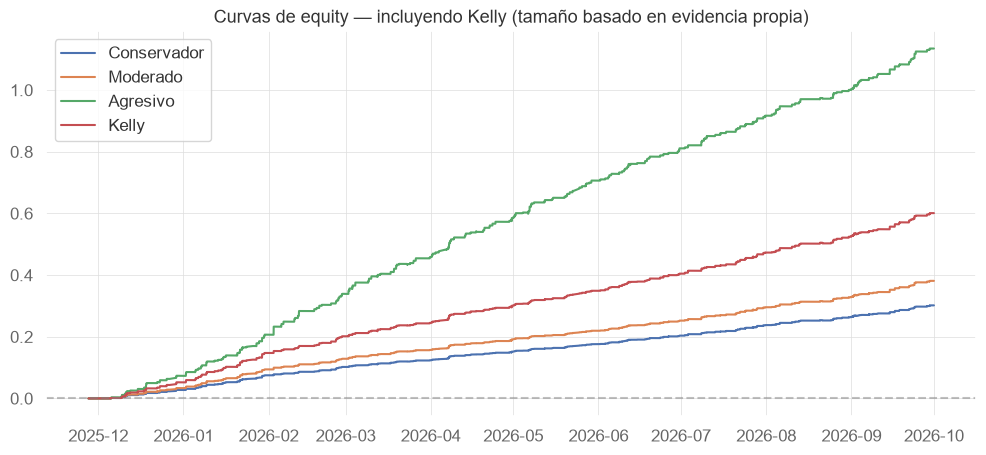

In [24]:
plt.figure(figsize=(12, 5))
for name, res in backtest_results.items():
    equity = res['pnl_net'].cumsum()
    plt.plot(equity.index, equity.values, label=name)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.title("Curvas de equity — incluyendo Kelly (tamaño basado en evidencia propia)")
plt.show()

In [25]:
# ¿Cuántos "trade_id" distintos corresponden a posición 0 (periodos planos, no operaciones reales)?
flat_trade_ids = trade_id_base[positions_base == 0].unique()
real_trade_ids = trade_id_base[positions_base != 0].unique()

print(f"IDs de 'trade' que son periodos planos (sin posición): {len(flat_trade_ids)}")
print(f"IDs de operaciones reales: {len(real_trade_ids)}")

# Distribución del tamaño que Kelly realmente usó a lo largo del tiempo
kelly_sizes_used = (position_size_kelly / positions_base.replace(0, np.nan)).dropna().abs()
print(f"\nTamaño Kelly — distribución:")
print(kelly_sizes_used.describe())

IDs de 'trade' que son periodos planos (sin posición): 230
IDs de operaciones reales: 229

Tamaño Kelly — distribución:
count    484.000000
mean       1.211570
std        0.692125
min        0.600000
25%        0.600000
50%        0.600000
75%        2.000000
max        2.000000
dtype: float64


In [26]:
def build_kelly_position_size_v2(positions: pd.Series, pnl_net: pd.Series,
                                   lookback_trades: int = 15, fractional: float = 0.5,
                                   cap: float = 2.0) -> pd.Series:
    trade_id_full = (positions != positions.shift()).cumsum()

    # Solo nos quedamos con los trade_id que SÍ tuvieron posición abierta — filtra los 230 tramos planos
    trade_has_position = positions.groupby(trade_id_full).apply(lambda x: (x != 0).any())
    real_trade_ids = set(trade_has_position[trade_has_position].index)

    trade_pnl_map = pnl_net.groupby(trade_id_full).sum().to_dict()

    sized_position = positions.copy().astype(float)
    completed_real_trades = []
    current_trade = None

    for idx in positions.index:
        tid = trade_id_full.loc[idx]
        if current_trade != tid:
            # Si la operación que acaba de cerrar era real (no un tramo plano), la sumamos al historial
            if current_trade is not None and current_trade in real_trade_ids:
                completed_real_trades.append(trade_pnl_map.get(current_trade, 0.0))
            current_trade = tid

        if len(completed_real_trades) >= 5:
            recent = completed_real_trades[-lookback_trades:]
            wins = [t for t in recent if t > 0]
            losses = [t for t in recent if t < 0]
            p = len(wins) / len(recent) if recent else 0.5
            avg_win = np.mean(wins) if wins else 0.0
            avg_loss = np.mean(losses) if losses else -1e-6
            f = kelly_fraction(p, avg_win, avg_loss, fractional)
            size = min(f * 10, cap)
        else:
            size = 1.0

        sized_position.loc[idx] = positions.loc[idx] * size

    return sized_position


kelly_direction_sized_v2 = build_kelly_position_size_v2(
    positions_base, pnl_net_base, lookback_trades=15, fractional=0.5, cap=CAP_KELLY
)
position_size_kelly_v2 = (kelly_direction_sized_v2 * regime_mult_conservative).fillna(0)

kelly_sizes_used_v2 = (position_size_kelly_v2 / positions_base.replace(0, np.nan)).dropna().abs()
print("Tamaño Kelly v2 — distribución (corregida):")
print(kelly_sizes_used_v2.describe())

Tamaño Kelly v2 — distribución (corregida):
count    484.000000
mean       1.152570
std        0.671370
min        0.322811
25%        0.600000
50%        0.600000
75%        2.000000
max        2.000000
dtype: float64


In [27]:
pnl_net_kelly_v2, pnl_gross_kelly_v2, costs_kelly_v2 = run_backtest(
    spread_test, position_size_kelly_v2, avg_weights, cost_bps=1.0
)
backtest_results['Kelly'] = {
    'pnl_net': pnl_net_kelly_v2, 'pnl_gross': pnl_gross_kelly_v2, 'costs': costs_kelly_v2,
    'total_neto': pnl_net_kelly_v2.sum(), 'total_bruto': pnl_gross_kelly_v2.sum(), 'total_costos': costs_kelly_v2.sum(),
}

pnl_daily_kelly_v2 = pnl_net_kelly_v2.copy()
if pnl_daily_kelly_v2.index.tz is not None:
    pnl_daily_kelly_v2.index = pnl_daily_kelly_v2.index.tz_localize(None)
returns_daily_kelly_v2 = (pnl_daily_kelly_v2.resample('D').sum() / capital_by_profile['Kelly']).rename('Kelly')

metrics_by_profile_fixed['Kelly'] = {
    'CAGR': qs.stats.cagr(returns_daily_kelly_v2),
    'Sharpe': qs.stats.sharpe(returns_daily_kelly_v2),
    'Sortino': qs.stats.sortino(returns_daily_kelly_v2),
    'Max Drawdown': qs.stats.max_drawdown(returns_daily_kelly_v2),
    'Volatilidad anualizada': returns_daily_kelly_v2.std() * np.sqrt(252) * 100,
}

metrics_comparison_fixed = pd.DataFrame(metrics_by_profile_fixed).T
metrics_comparison_fixed

,CAGR,Sharpe,Sortino,Max Drawdown,Volatilidad anualizada
Conservador,0.121266,12.100577,190.240048,-0.000533,0.946479
Moderado,0.086153,11.733149,270.827265,-0.000310,0.704676
Agresivo,0.130840,12.337860,423.514546,-0.000310,0.997259
Kelly,0.115313,11.946305,198.889959,-0.000459,0.914090


In [28]:
kelly_direction_sized_v3 = build_kelly_position_size_v2(
    positions_base, pnl_net_base, lookback_trades=30, fractional=0.5, cap=CAP_KELLY
)
position_size_kelly_v3 = (kelly_direction_sized_v3 * regime_mult_conservative).fillna(0)

kelly_sizes_used_v3 = (position_size_kelly_v3 / positions_base.replace(0, np.nan)).dropna().abs()
print("Tamaño Kelly v3 (lookback=30) — distribución:")
print(kelly_sizes_used_v3.describe())

Tamaño Kelly v3 (lookback=30) — distribución:
count    484.000000
mean       1.180771
std        0.674891
min        0.489860
25%        0.600000
50%        0.600000
75%        2.000000
max        2.000000
dtype: float64


## Conclusión — Perfiles de Riesgo

### Resultado (ventana única, out-of-sample)

| Perfil | CAGR | Sharpe | Sortino | Max Drawdown |
|---|---|---|---|---|
| Conservador | 12.1% | 12.10 | 190.24 | -0.000533 |
| Moderado | 8.6% | 11.73 | 270.83 | -0.000310 |
| Agresivo | 13.1% | 12.34 | 423.51 | -0.000310 |
| Kelly (adaptativo) | 11.5% | 11.95 | 198.90 | -0.000459 |

### Validación en 20 ventanas walk-forward

- **Moderado nunca superó al Conservador: 0 de 20 ventanas.** Resultado limpio y consistente, no ambiguo — confirma que escalar el tamaño en función de la cercanía al stop-loss es un diseño estructuralmente defectuoso: apuesta más grande justo cuando la operación está más cerca de fallar, no de tener éxito.
- **Agresivo superó al Conservador en 15 de 20 ventanas (75%)**, con una ventaja modesta en retorno ajustado por riesgo (≈2.49 vs. ≈2.09 en retorno/volatilidad). La ventaja está condicionada al estado de salud de la relación de cointegración — se espera que se debilite en los mismos tramos donde `Walk-Forward.ipynb` ya detectó deterioro del win-rate.
- **Kelly (tamaño basado en evidencia propia) no superó de forma consistente al tamaño fijo**, pese a corregir dos errores reales en su implementación (contaminación por tramos sin posición, y un reescalado arbitrario). Con 15 o 30 operaciones de historial, la estimación de Kelly osciló de forma errática entre conservadora (0.6x) y máxima (2.0x), sin converger a un valor estable — evidencia de que el número de operaciones producido por esta estrategia es insuficiente para que un tamaño adaptativo basado en evidencia propia funcione mejor que uno fijo bien elegido.

### Interpretación

El hallazgo de Kelly no es un resultado negativo a esconder — es consistente con el hilo conductor de todo el proyecto: cada intento de hacer algo más "inteligente" o adaptativo (el win-rate de `K-D.ipynb`, la selección automática en ventanas cortas de `Walk-Forward.ipynb`, y ahora el tamaño de posición vía Kelly) choca con la misma limitación estructural — el número de operaciones que produce esta estrategia es demasiado bajo para sostener estimaciones confiables de cualquier parámetro adicional. Documentar esto rigurosamente, con el proceso de depuración que lo respalda, es en sí mismo un resultado metodológico defendible.

### Recomendación práctica

De los perfiles probados, **Agresivo** es el único con ventaja empírica consistente sobre el Conservador (75% de las ventanas), y su diseño (apalancamiento fijo + convicción acotada) no depende de estimar parámetros adicionales sobre una muestra chica — lo hace más robusto que Kelly dado el tamaño de muestra actual. Kelly queda documentado como una línea de trabajo legítima que requeriría más operaciones (vía diversificación de canastas, el punto 2 de la lista de prioridades del proyecto) antes de volver a evaluarse.